In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("linear_regression_dataset.csv")
df.head()

,AGE,FEMALE,LOS,RACE,TOTCHG,APRDRG
0,17,1,2,1.0,2660,560
1,17,0,2,1.0,1689,753
2,17,1,7,1.0,20060,930
3,17,1,1,1.0,736,758
4,17,1,1,1.0,1194,754


In [17]:
df.shape

(500, 6)

In [18]:
df.isnull().sum()

AGE       0
FEMALE    0
LOS       0
RACE      1
TOTCHG    0
APRDRG    0
dtype: int64

In [19]:
df_clean = df.dropna().copy()

print(df_clean.shape)

(499, 6)


In [20]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ['AGE', 'LOS']
categorical_cols = ['RACE', 'APRDRG']

df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

scaler_X = StandardScaler()
df_clean[continuous_cols] = scaler_X.fit_transform(df_clean[continuous_cols])

scaler_Y = StandardScaler()
df_clean['TOTCHG'] = scaler_Y.fit_transform(df_clean[['TOTCHG']])
df_clean = df_clean.astype(float)

In [21]:
def gradient_decent(weights, c, X, Y, L):
    n = len(Y)
    num_features = len(weights)
    weights_gradient = [0] * num_features
    c_gradient = 0
    for i in range(n):
        y = Y[i]
        pred = c
        for j in range(num_features):
            pred += weights[j] * X[i][j]
        for j in range(num_features):
            weights_gradient[j] += -(2/n) * X[i][j] * (y - pred)
        c_gradient += -(2/n) * (y - pred)
    new_weight = [0] * num_features
    for j in range(num_features):
        new_weight[j] = weights[j] - (weights_gradient[j] * L)
    new_c = c - (c_gradient * L)
    return new_weight, new_c

In [22]:
Y_data = df_clean['TOTCHG'].values
X_data = df_clean.drop('TOTCHG', axis=1).values
num_features = X_data.shape[1]
m = [0] * num_features
b = 0
L = 0.0001
epoch = 5000

for i in range(epoch):
    m, b = gradient_decent(m, b, X_data, Y_data, L)

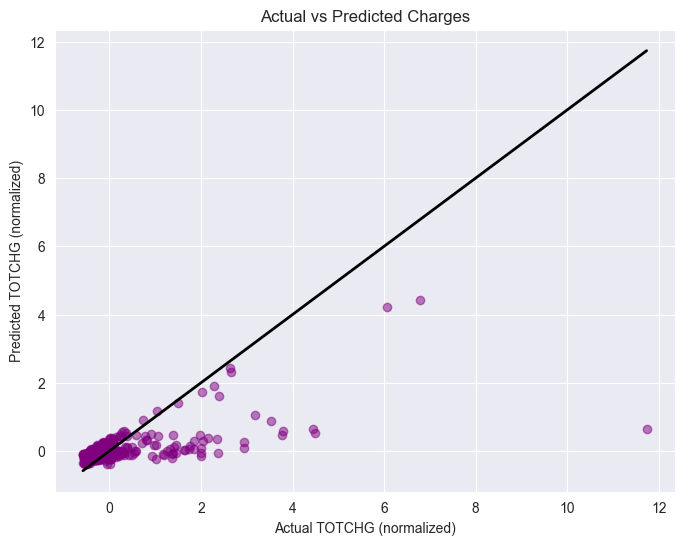

In [23]:
predictions = []
for i in range(len(Y_data)):
    pred = b
    for j in range(num_features):
        pred += m[j] * X_data[i][j]
    predictions.append(pred)

plt.figure(figsize=(8, 6))
plt.scatter(Y_data, predictions, color='purple', alpha=0.5)

min_val = min(min(Y_data), min(predictions))
max_val = max(max(Y_data), max(predictions))
plt.plot([min_val, max_val], [min_val, max_val], color='black', linewidth=2)

plt.xlabel("Actual TOTCHG (normalized)")
plt.ylabel("Predicted TOTCHG (normalized)")
plt.title("Actual vs Predicted Charges")
plt.show()